# Assignment 2: Type 1a Supernovae 
## Ishna Tripathi, 23373580
### Trinity College Dublin

#### Notes
Measure expansion using parallax - only local

Using Cepheids we can meaure further away and cepheids to measure supernovae. 

$z = \lambda_{obs} - \lambda_{rest} / \lambda_{rest} $

Cosmological redshift - measure the change in emission line to see the redshift.

Hubble looked at the cepheid period-luminosity relationship. 

- Graphed recession velocity (km/s) vs distance (Mpc)

Higher redshifts with supernovar, same brightness just different distances. 

Get recesssional velocity from the measured galaxy spectra and graph against the distance.

## Part a: Measuring redshift from spectra

In [18]:
# Importing all the necessay modules
import numpy as np
import matplotlib.pyplot as plt
import os
from numpy.polynomial import Polynomial as poly
from scipy.optimize import curve_fit
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
import pandas as pd
import supernovae as sp # this is my module that includes all the functions for this code

In [19]:
# Set the directory and file name - QA
directory = r'/Users/ishnatripathi/Documents/ML_projects/' # Directory of my file

# Iterating my function for each file in the directory
for file_name in os.listdir(directory): # For all the files in y directory
    if file_name.endswith('.ascii'): # Take the files that end in ascii
        file_path = os.path.join(directory, file_name) # Make the file path
        sp.galaxies(file_path) # Running each file path into the function
        #galaxies(file_path) # Running each file path into the function

In [20]:
# Graphing for the spectral lines (H alpha)
files = sorted([f for f in os.listdir(directory) if f.endswith(".ascii")]) # getting all the files in the directory in specific order becuase each graph requires a specific mask
z_list = []
h_alpha = 6563.0
CAII = 3969.0
NaI = 5890.0
z_err_list = []
# Iterating through each file
for i, file_name in enumerate(files): 
    file_path = os.path.join(directory, file_name)
    # For the 1, 2, 4, the masks are 6600 - 6700
    if i in [0,1, 3]:
        wl_min, wl_max = 6600, 6700
    elif i in [2]:
        # For the 3, the masks are 65000 - 6700
        wl_min, wl_max = 6500, 6700
    elif i in [4,6, 5]:
        # For the 5 the masks are 6600 - 6800
        wl_min, wl_max = 6600, 6800
    else:
        continue
    
    # Running the definition itself to find the peaks
    popt, pcov, z, z_err = sp.analyze_spectrum(file_path=file_path, wl_min=wl_min, wl_max=wl_max, rest_line=6563.0)
    z_list.append(z)
    z_err_list.append(z_err)
z = np.array(z_list)
'''
# For CaII
for i, file_name in enumerate(files):
    file_path = os.path.join(directory, file_name)

    if i in [3]:
        wl_min, wl_max = 3700, 3750
    elif i in [4]:
        wl_min, wl_max = 3660, 3700
    else:
        continue
    popt, pcov, z = sp.analyze_spectrum(file_path=file_path, wl_min = wl_min, wl_max = wl_max, rest_line = NaI)    
    z_list.append(z)

# For OIII
OIII = 5007
for i, file_name in enumerate(files):
    file_path = os.path.join(directory, file_name)

    if i in [5]:
        wl_min, wl_max = 5110, 5140
    else:
        continue
    popt, pcov, z = sp.analyze_spectrum(file_path=file_path, wl_min = wl_min, wl_max = wl_max, rest_line = OIII)    
    z_list.append(z)
'''

'\n# For CaII\nfor i, file_name in enumerate(files):\n    file_path = os.path.join(directory, file_name)\n\n    if i in [3]:\n        wl_min, wl_max = 3700, 3750\n    elif i in [4]:\n        wl_min, wl_max = 3660, 3700\n    else:\n        continue\n    popt, pcov, z = sp.analyze_spectrum(file_path=file_path, wl_min = wl_min, wl_max = wl_max, rest_line = NaI)    \n    z_list.append(z)\n\n# For OIII\nOIII = 5007\nfor i, file_name in enumerate(files):\n    file_path = os.path.join(directory, file_name)\n\n    if i in [5]:\n        wl_min, wl_max = 5110, 5140\n    else:\n        continue\n    popt, pcov, z = sp.analyze_spectrum(file_path=file_path, wl_min = wl_min, wl_max = wl_max, rest_line = OIII)    \n    z_list.append(z)\n'

## Part B: measuring properties of Type 1a Supernovae light curves
## Part C: light-curve standardisation and the Hubble Diagram

In [22]:
# Loading file directory for the LC files
file_dir_LC = r'/Users/ishnatripathi/Documents/ML_projects/Data_for_download_part1/SN_lightcurves'

# Collecting all values in a list
absolute_mag = []
d15s = []
mu = []
peak = []

file_list = os.listdir(file_dir_LC) # finding list directory

file_list = sorted([f for f in os.listdir(file_dir_LC) if f.endswith(".dat")]) # sorting out lists so that each z value corresponds to the right spectra

# Applying the LC code to each file
for i, file_name in enumerate(file_list):
    file = os.path.join(file_dir_LC, file_name)

    # Create a cosmology model: FlatLambdaCDM = Flat universe (Ω_k = 0), Om0 = matter density parameter Ω_m today (0.3), this implies Ω_Λ = 1 − Ω_m = 0.7 (dark energy density)
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

    # Compute luminosity distance for supernova at redshift z[i], luminosity_distance(z) returns a Quantity in units of Mpc, .to(u.pc) converts from megaparsecs → parsecs, .value strips the unit and returns a plain float
    d_L = cosmo.luminosity_distance(z[i]).to(u.pc).value

    peaks, d15, b_mag_err = sp.lc(file, z[i]) # access through my module
    print(f"Peaks: {peaks}")
    print(f"delta_m: {d15}")
    
    # Appending values to a list
    mus = 5 * np.log10(d_L / 10) # getting mu = m - M = 5 log(d_L / 10)
    mu.append(mus)
    MB = peaks - mus # getting absolute magnitude
    d15s.append(d15)
    absolute_mag.append(MB)
    peak.append(peaks)

print(f"Peaks: {peaks}")
print(f"delta_m: {d15}")


IndexError: index 0 is out of bounds for axis 0 with size 0

slope = 0.7249127334255799
intercept = -19.62057392970714


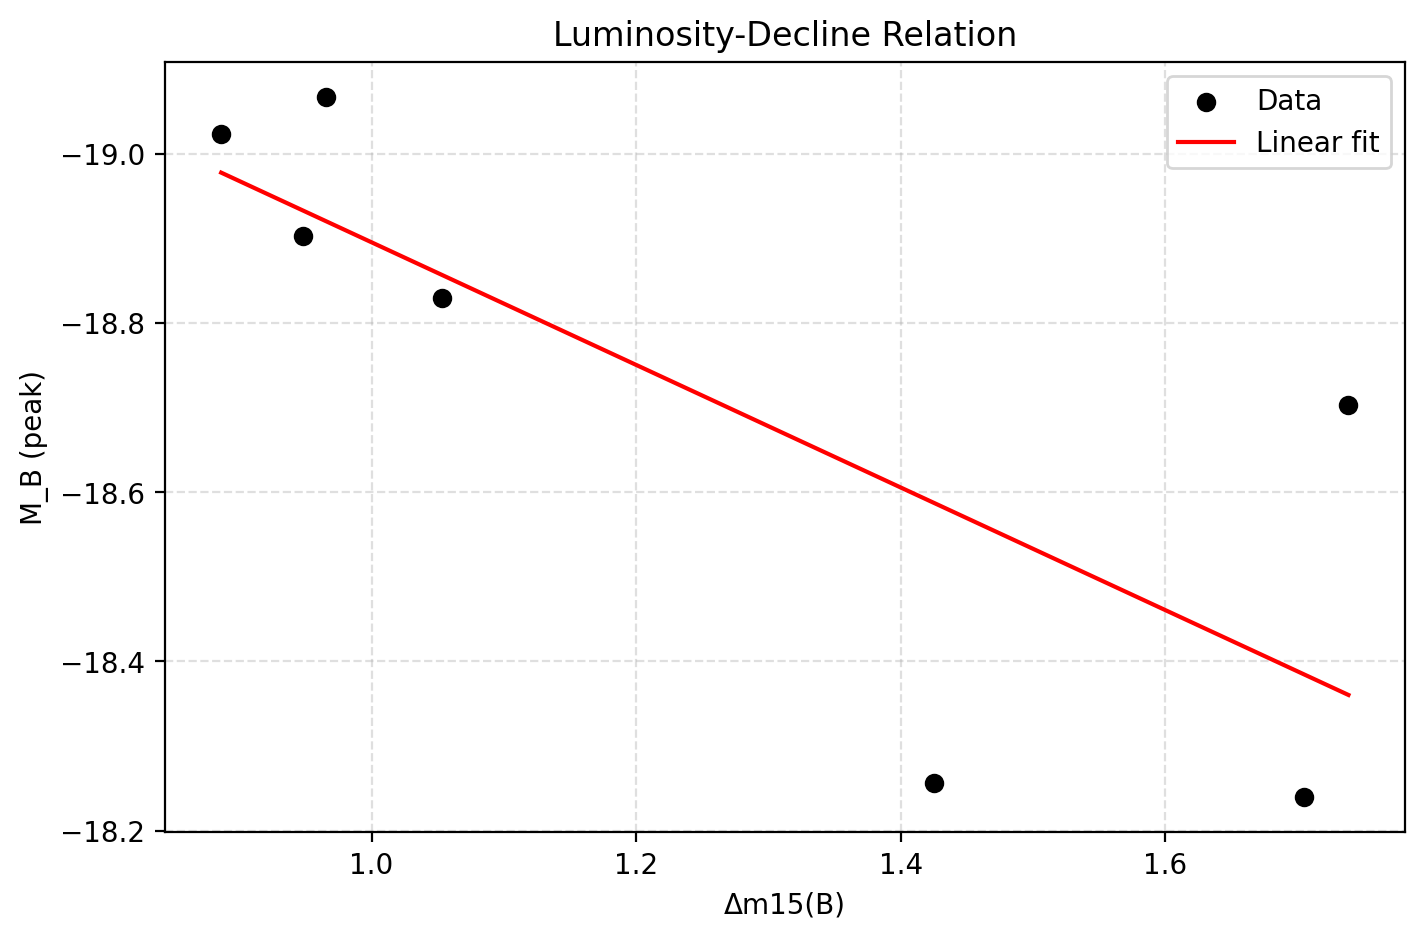

In [ ]:
## Luminosity Decline Relation

c = 3e5  # km/s

peaks = np.array(peak) # m_B peak (apparent)
d15 = np.array(d15s) # delta m15
absolute_mag = np.array(absolute_mag) # Absolute magnitude
mu = np.array(mu) # distance modulus from cosmology
z_arr = np.array(z)

# mask out anything invalid
ok = np.isfinite(peaks) & np.isfinite(d15) & np.isfinite(mu) & np.isfinite(z_arr) & (z_arr > 0)
peaks_ok = peaks[ok]
d15_ok = d15[ok]
mu_ok = mu[ok]
z_ok = z_arr[ok]
absolute_mag = absolute_mag[ok]

# Get the log(cz), data to fit
log_cz = np.log10(c * z_ok)
coeffs = np.polyfit(d15_ok, absolute_mag, deg=1)
slope, intercept = coeffs
MB_fit = slope * d15_ok + intercept

print("slope =", slope)
print("intercept =", intercept)

# Plot Phillips relation style
dm_grid = np.linspace(d15_ok.min(), d15_ok.max(), 500)
plt.figure(figsize=(8,5), dpi=200)
plt.scatter(d15_ok, absolute_mag, label="Data", color = 'k')
plt.plot(dm_grid, slope*dm_grid + intercept, label="Linear fit", color = 'r')
plt.gca().invert_yaxis()
plt.xlabel("Δm15(B)")
plt.ylabel("M_B (peak)")
plt.title("Luminosity-Decline Relation")
plt.grid(ls="--", alpha=0.4)
plt.legend()
plt.show()

slope = 6.521998880936532
intercept = -8.410147994229078
slope = 4.957570851740904
intercept = -2.882334194445337


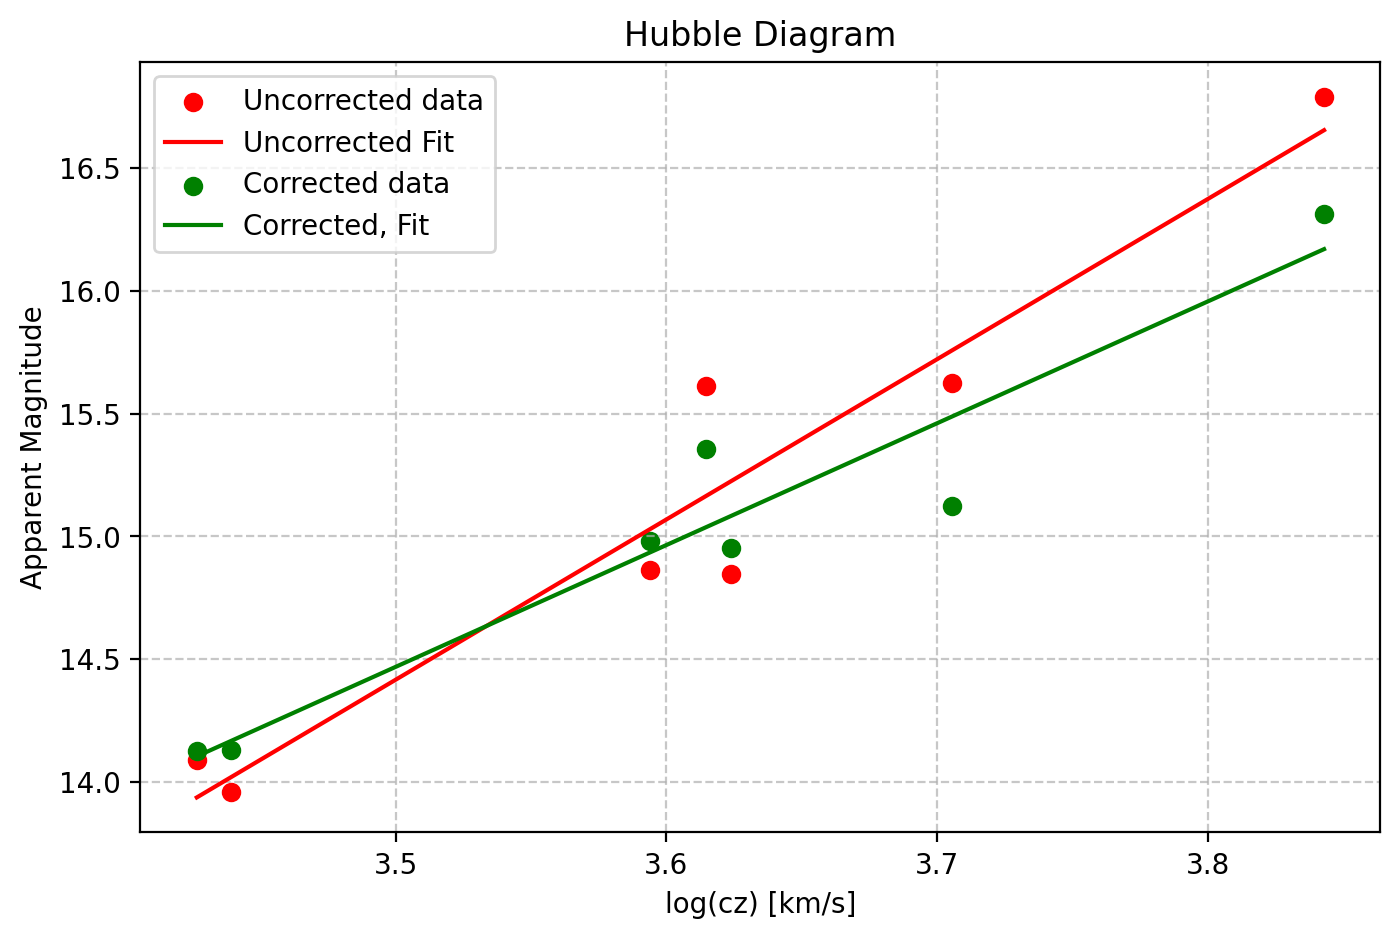

In [ ]:
## Hubble Diagram
log_cz = np.log10(c*z)

coeffs = np.polyfit(log_cz, peaks, deg=1)  
p2 = np.poly1d(coeffs)

dm_min = np.min(log_cz)
dm_max = np.max(log_cz)
dm_grid = np.linspace(dm_min, dm_max, 500)

slope = coeffs[0]
intercept = coeffs[1]
print("slope =", slope)
print("intercept =", intercept)
plt.figure(figsize=(8,5), dpi=200)

# Plot the uncorrected
plt.scatter(log_cz, peaks, color = 'r', label = 'Uncorrected data')
plt.plot(dm_grid, p2(dm_grid), color = 'r', label = (f"Uncorrected Fit"))

# Find corrected data
corrected = peaks - 0.7847705285409476 * (d15 - 1.1)
coeffs = np.polyfit(log_cz, corrected, deg=1)  
p2 = np.poly1d(coeffs)

dm_min = np.min(log_cz)
dm_max = np.max(log_cz)
dm_grid = np.linspace(dm_min, dm_max, 500)

slope = coeffs[0]
intercept = coeffs[1]
print("slope =", slope)
print("intercept =", intercept)

# Plot the two
d15 = np.array(d15s)
plt.scatter(log_cz, corrected, color = 'g', label = 'Corrected data')
plt.plot(dm_grid, p2(dm_grid), color = 'g', label = (f"Corrected, Fit"))
plt.title("Hubble Diagram")
plt.xlabel("log(cz) [km/s]")
plt.ylabel("Apparent Magnitude")
plt.legend()
plt.grid(ls = '--', alpha = 0.7)
plt.show()

### Part D:  a modern supernova sample, the Joint Light Curve Analysis

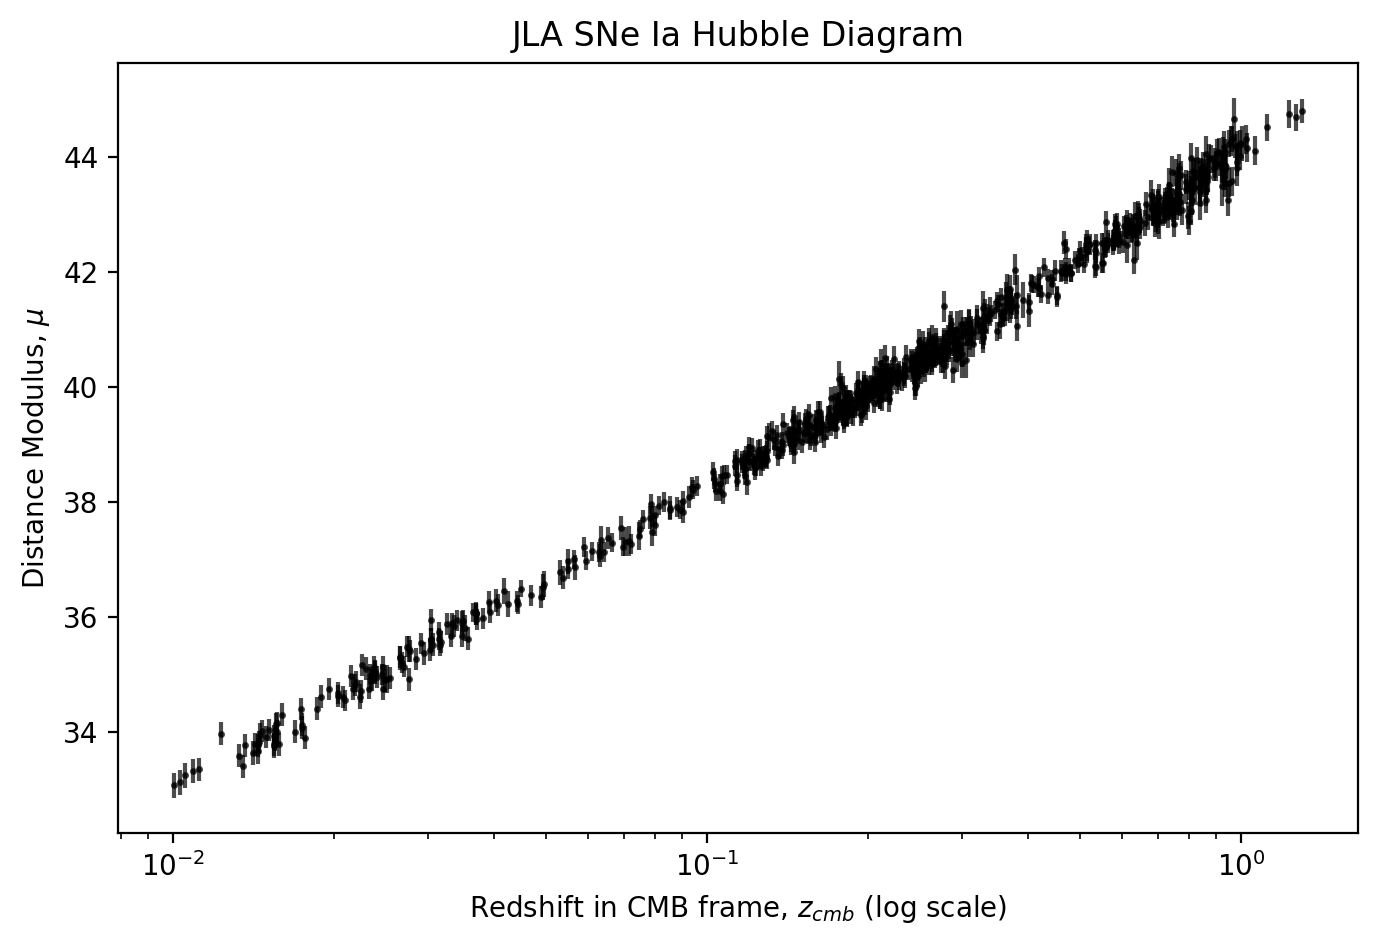

N = 740
Chi^2 (massless/Eqn7 approx) = 579.5 reduced ~ 0.783
Chi^2 (flat LCDM Om0=0.3) = 606.4 reduced ~ 0.819
Chi^2 (flat matter Om0=1) = 1711.1 reduced ~ 2.312


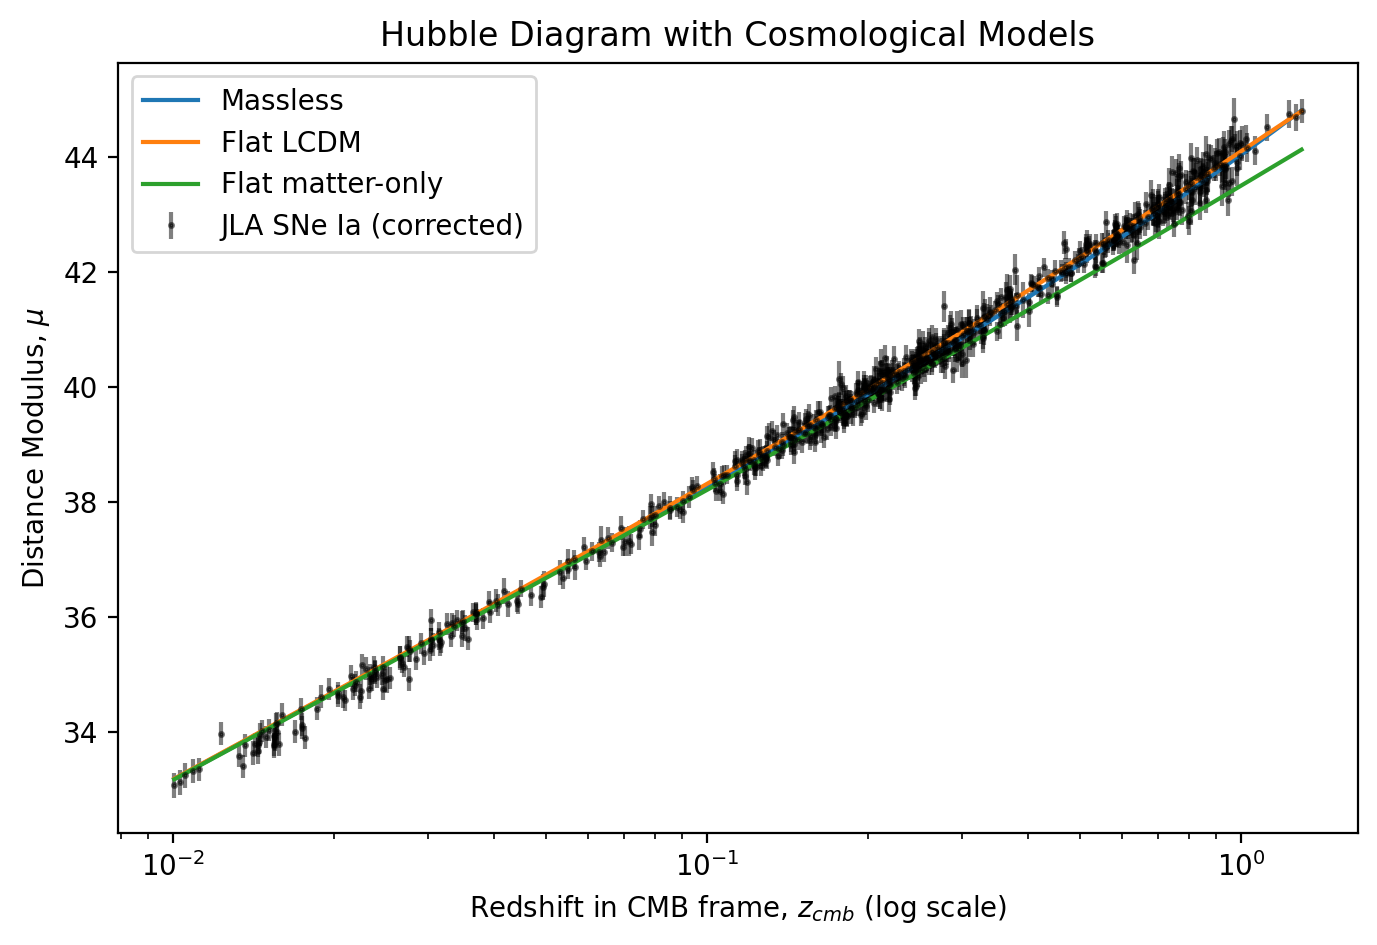

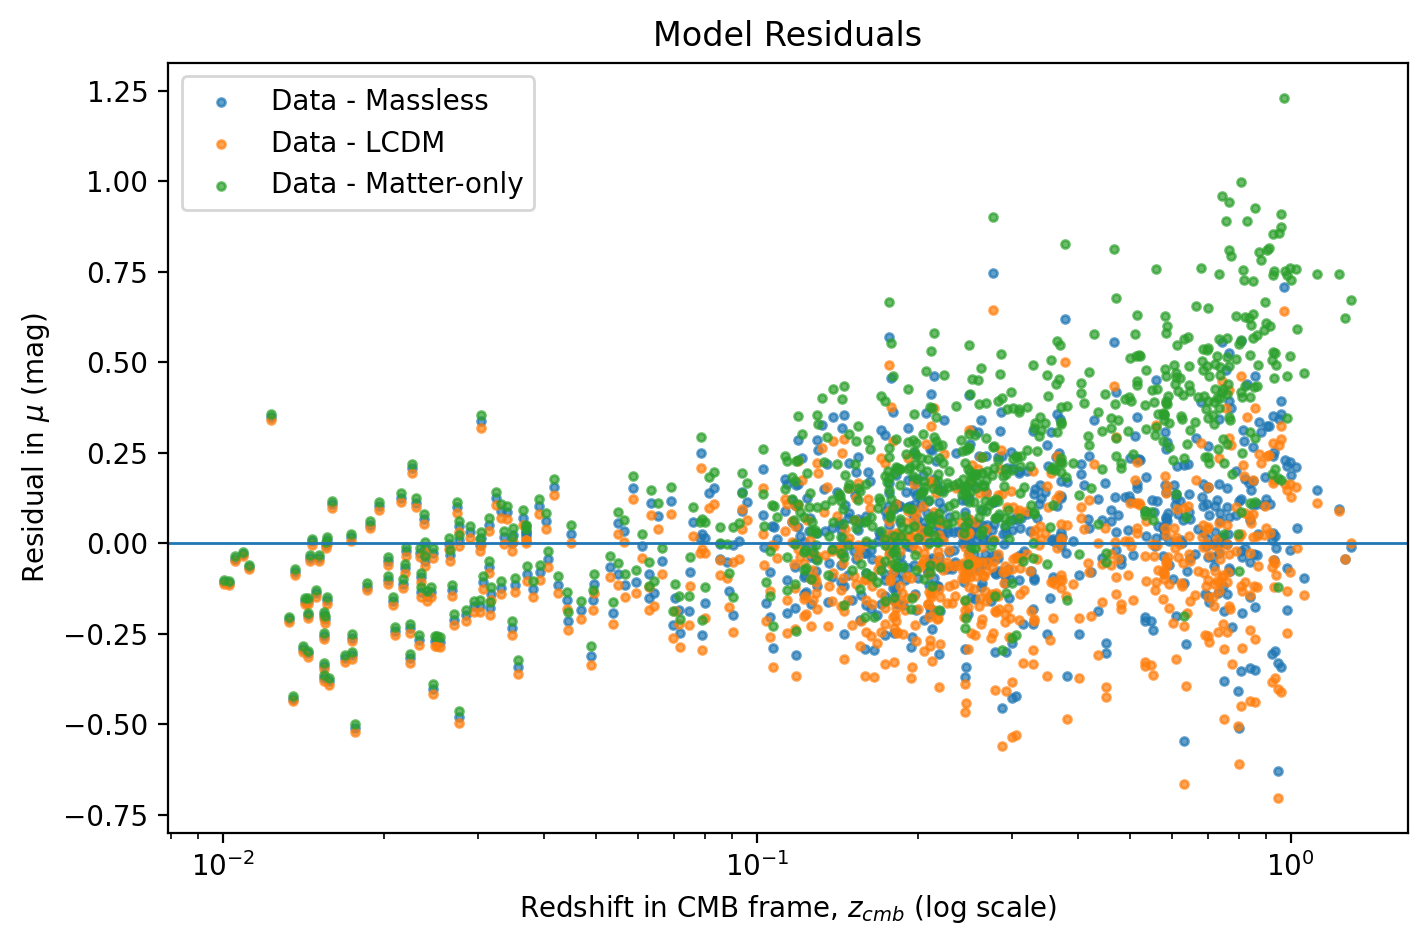

In [ ]:
# Get the directory of the file
dpath = r"C:/Users/ishna/Desktop/Astrophysics Labs - Y3/Data_for_download_part2/Allsupernovae.csv"
data = pd.read_csv(dpath)

# Extract the data and put it into a dataframe
zcmb = data["zcmb"].to_numpy()
logmst = data["LogMst"].to_numpy()
x1 = data["X1"].to_numpy()
c1 = data["c"].to_numpy()
mb = data["mb"].to_numpy()
# Errors
err_mb = data["error_mb"].to_numpy()
err_x1 = data["error_X1"].to_numpy()
err_c1 = data["error_c"].to_numpy()

# Using the values we were given
alpha = 0.141
beta  = 3.101
MB    = -19.05
delta_m = -0.07

# Mass step - mass correction
mass_step = np.where(logmst > 10, delta_m, 0.0)

# Observed distance modulus
mu_obs = (mb - MB + alpha * x1 - beta * c1 + mass_step)

# Uncertainty propagation for mu
sigma_mu = np.sqrt(err_mb**2 + (alpha * err_x1)**2 + (beta * err_c1)**2)
sigma_int = 0.10
sigma_mu_tot = np.sqrt(sigma_mu**2 + sigma_int**2)

# Filter invalid rows
mask = np.isfinite(zcmb) & np.isfinite(mu_obs) & np.isfinite(sigma_mu_tot) & (zcmb > 0) & (sigma_mu_tot > 0)
z = zcmb[mask]
mu = mu_obs[mask]
sig = sigma_mu_tot[mask]

# Plotting Hubble Diagram
plt.figure(figsize=(8,5), dpi=200)
plt.errorbar(z, mu, yerr=sig, fmt='.', ms=3, capsize=0, alpha=0.7, color = 'black')
plt.xscale("log") # log scale
plt.xlabel("Redshift in CMB frame, $z_{cmb}$ (log scale)")
plt.ylabel("Distance Modulus, $\\mu$")
plt.title("JLA SNe Ia Hubble Diagram")
plt.show()

## Cosmological Models
c_km_s = 299792.458
H0 = 70.0  # km/s/Mpc

def mu_from_dL_Mpc(dL_Mpc):
    """Distance modulus from luminosity distance in Mpc."""
    return 5.0 * np.log10(dL_Mpc) + 25.0

# Massless model
def dL_massless_Mpc(z):
    return (c_km_s / H0) * (z * (1.0 + 0.5*z))

# Flat LCDM
cosmo_lcdm = FlatLambdaCDM(H0=H0, Om0=0.3)

#Flat matter-only
cosmo_matter = FlatLambdaCDM(H0=H0, Om0=1.0)

# Compute model mus
mu_massless = mu_from_dL_Mpc(dL_massless_Mpc(z))
mu_lcdm = mu_from_dL_Mpc(cosmo_lcdm.luminosity_distance(z).to(u.Mpc).value)
mu_matter = mu_from_dL_Mpc(cosmo_matter.luminosity_distance(z).to(u.Mpc).value)

# Residuals (data -model)
res_massless = mu - mu_massless
res_lcdm = mu - mu_lcdm
res_matter = mu - mu_matter

# Chi^2 
def chi2(residuals, sigma):
    return np.sum((residuals / sigma)**2)

N = len(z) # dataset
chi2_massless = chi2(res_massless, sig)
chi2_lcdm = chi2(res_lcdm, sig)
chi2_matter = chi2(res_matter, sig)

# Print chi squared
print(f"N = {N}")
print(f"Chi^2 (massless/Eqn7 approx) = {chi2_massless:.1f} reduced ~ {chi2_massless/N:.3f}")
print(f"Chi^2 (flat LCDM Om0=0.3) = {chi2_lcdm:.1f} reduced ~ {chi2_lcdm/N:.3f}")
print(f"Chi^2 (flat matter Om0=1) = {chi2_matter:.1f} reduced ~ {chi2_matter/N:.3f}")

## Model Curves Plotting
# Make grid for line of best fit
zgrid = np.logspace(np.log10(z.min()), np.log10(z.max()), 400)
mu_massless_grid = mu_from_dL_Mpc(dL_massless_Mpc(zgrid))
mu_lcdm_grid = mu_from_dL_Mpc(cosmo_lcdm.luminosity_distance(zgrid).to(u.Mpc).value)
mu_matter_grid = mu_from_dL_Mpc(cosmo_matter.luminosity_distance(zgrid).to(u.Mpc).value)

# Plotting
plt.figure(figsize=(8,5), dpi=200)
plt.errorbar(z, mu, yerr=sig, fmt='.', ms=3, capsize=0, alpha=0.5, label="JLA SNe Ia (corrected)", color = 'black')
plt.plot(zgrid, mu_massless_grid, label="Massless")
plt.plot(zgrid, mu_lcdm_grid, label="Flat LCDM")
plt.plot(zgrid, mu_matter_grid, label="Flat matter-only")
plt.xscale("log")
plt.xlabel("Redshift in CMB frame, $z_{cmb}$ (log scale)")
plt.ylabel("Distance Modulus, $\\mu$")
plt.title("Hubble Diagram with Cosmological Models")
plt.legend()
plt.show()

## Residuals plot
plt.figure(figsize=(8,5), dpi=200)
plt.axhline(0, lw=1)
plt.scatter(z, res_massless, s=8, label="Data - Massless", alpha=0.7)
plt.scatter(z, res_lcdm, s=8, label="Data - LCDM", alpha=0.7)
plt.scatter(z, res_matter, s=8, label="Data - Matter-only", alpha=0.7)
plt.xscale("log")
plt.xlabel("Redshift in CMB frame, $z_{cmb}$ (log scale)")
plt.ylabel("Residual in $\\mu$ (mag)")
plt.title("Model Residuals")
plt.legend()
plt.show()